<a href="https://colab.research.google.com/github/Rifath-Mahmud/CVPR/blob/main/CNN_CIFAR10_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
data_folder = '~/data/FMNIST' # This can be any directory you
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# want to download FMNIST to
train_data = datasets.CIFAR10(data_folder, train=True, download=True, transform = transform)
tr_images = train_data.data
tr_targets = train_data.targets
test_data = datasets.CIFAR10(data_folder, train=False, download=True, transform = transform)
val_images = test_data.data
val_targets = test_data.targets

cuda


In [57]:
bath_size_no = 32
learning_rate=1e-3
epoch_number = 10

In [63]:
class CIFAR10(Dataset):
    def __init__(self, x, y):
        x = torch.tensor(x)
        x = x.float()/255
        x = x.permute(0,3,1,2)
        x = x.view(-1,3,32,32)

        y = torch.tensor(y)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)

def get_data():
    train = CIFAR10(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=bath_size_no, shuffle=True)
    val = CIFAR10(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=True)
    return trn_dl, val_dl

In [64]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(128*6*6, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()

@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [65]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [66]:
from torchsummary import summary
model, loss_fn, optimizer = get_model()
summary(model, input_size=(3,32,32));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 30, 30]           1,792
         MaxPool2d-2           [-1, 64, 15, 15]               0
              ReLU-3           [-1, 64, 15, 15]               0
            Conv2d-4          [-1, 128, 13, 13]          73,856
         MaxPool2d-5            [-1, 128, 6, 6]               0
              ReLU-6            [-1, 128, 6, 6]               0
           Flatten-7                 [-1, 4608]               0
            Linear-8                  [-1, 256]       1,179,904
              ReLU-9                  [-1, 256]               0
           Linear-10                   [-1, 10]           2,570
Total params: 1,258,122
Trainable params: 1,258,122
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.93
Params size (MB): 4.80
Estimat

In [67]:
from torch import optim
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                  factor=0.5, patience=0,
                                  threshold = 0.001,
                                  min_lr = 1e-5,
                                  threshold_mode = 'abs')

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(epoch_number):
    print(f'--------Epoch Number : {epoch}----------')
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
        scheduler.step(validation_loss)
        print(f'Current Learning Rate:{scheduler.get_last_lr()[0]}')
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    print(f'Epoch Loss:{train_epoch_loss}')
    train_accuracies.append(train_epoch_accuracy)
    print(f'Epoch Accuracy:{train_epoch_accuracy}')
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

--------Epoch Number : 0----------
Current Learning Rate:0.001
Epoch Loss:1.3808590882646679
Epoch Accuracy:0.61606
--------Epoch Number : 1----------
Current Learning Rate:0.001
Epoch Loss:1.0102281410077865
Epoch Accuracy:0.70782
--------Epoch Number : 2----------
Current Learning Rate:0.001
Epoch Loss:0.8520667771269553
Epoch Accuracy:0.7592
--------Epoch Number : 3----------
Current Learning Rate:0.0005
Epoch Loss:0.7242529592640645
Epoch Accuracy:0.77966
--------Epoch Number : 4----------
Current Learning Rate:0.0005
Epoch Loss:0.5452635346775396
Epoch Accuracy:0.85034
--------Epoch Number : 5----------
Current Learning Rate:0.00025
Epoch Loss:0.4676131046188236
Epoch Accuracy:0.87558
--------Epoch Number : 6----------
Current Learning Rate:0.000125
Epoch Loss:0.35658100826078243
Epoch Accuracy:0.9052
--------Epoch Number : 7----------
Current Learning Rate:6.25e-05
Epoch Loss:0.29469774002048427
Epoch Accuracy:0.9218
--------Epoch Number : 8----------
Current Learning Rate:3.125e

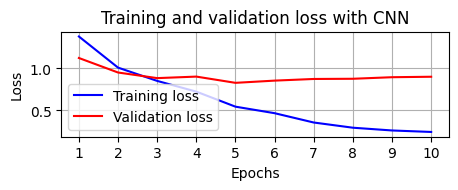

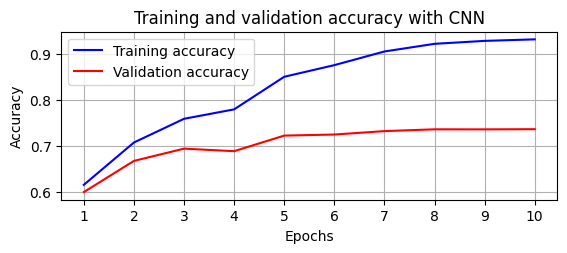

In [68]:
epochs = np.arange(epoch_number)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.figure(figsize=(5,3))
plt.subplot(211)
plt.plot(epochs, train_losses, 'b', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with CNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'b', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
#plt.ylim(0.8,1)
#plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid('off')
plt.show()

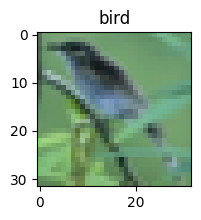

In [105]:
ix = torch.randint(0,1000,())
img = tr_images[ix]/255.0
img = torch.Tensor(img).permute(2,0,1).unsqueeze(0).to(device)
np_output = model(img).cpu().detach().numpy()
pred = np.exp(np_output)/np.sum(np.exp(np_output))
plt.figure(figsize=(2,2))
plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
plt.title(train_data.classes[pred[0].argmax()])
plt.show()